# 해커톤: 기존 분류 결과 재현과 whitening 비교

이 노트북은 hhlee가 맡은 실험을 진행하는 파일입니다.

목표는 팀원의 기존 `classify.py` 결과를 확인한 뒤, spectral whitening을 추가했을 때 성능이 달라지는지 같은 조건으로 비교하는 것입니다.

현재는 **기존 코드를 실행할 준비까지 완료**했습니다. 아래 실행 셀은 아직 실행하지 않았고, whitening 구현도 아직 추가하지 않았습니다.


## 사용할 파일

- 이 노트북의 위치: `/Users/hhlee/hackathon_project/01_baseline_whitening.ipynb`
- `source/`: 팀원이 공유한 9개 파일의 작업용 사본
- 원본 위치: `/Users/hhlee/Downloads/Hackathon-20261004T203725Z-1-001/Hackathon`

`ECoG_Handpose.mat`에는 ECoG 전극 신호 60개, 동작 지시, 손가락 센서 5개와 시간이 들어 있습니다. 가위·바위·보 지시는 각각 30회이고, 샘플링 주파수는 1200 Hz입니다.

**`source/join_mat.py`는 실행하지 않습니다.** 현재는 완성된 `.mat` 파일이 있고 분할 파일이 없으므로, 이 도구를 실행하면 데이터 사본이 빈 파일로 덮어써집니다.


## 1. Python 환경과 데이터 위치 확인

다음 셀은 사용하는 Python 경로와 데이터 배열의 크기를 표시합니다. 첫 번째 실행은 이 확인 셀부터 시작합니다.

Python 경로는 `/Users/hhlee/miniconda3/envs/ecog/bin/python`이어야 합니다. 데이터 변수 `y`의 크기는 `(67, 507025)`로 확인했습니다.


In [3]:
from pathlib import Path
import sys
from scipy.io import whosmat

source_directory = Path("source").resolve()
data_path = source_directory / "ECoG_Handpose.mat"

print("현재 Python:", sys.executable)
print("작업용 데이터:", data_path)
print("기존 분류 코드:", source_directory / "classify.py")
for variable_name, variable_shape, variable_type in whosmat(data_path):
    print(f"변수 {variable_name}: {variable_shape[0]:,}행 × {variable_shape[1]:,}열, 자료형 {variable_type}")


현재 Python: /Users/hhlee/miniconda3/envs/ecog/bin/python
작업용 데이터: /Users/hhlee/hackathon_project/source/ECoG_Handpose.mat
기존 분류 코드: /Users/hhlee/hackathon_project/source/classify.py
변수 y: 67행 × 507,025열, 자료형 double


## 2. 팀원의 기존 분류 코드 실행

이 셀은 작업용 사본의 `classify.py`를 그대로 실행합니다. 첫 번째 확인 셀을 실행한 다음 사용합니다.

코드는 공통 잡음과 느린 변화를 제거하고, 전원 잡음을 걸러낸 뒤, 50–300 Hz 신호의 크기를 특징으로 사용합니다. 전극 60개와 시간 구간 8개를 합쳐 trial당 특징 480개를 만들고 LDA로 손동작을 구분합니다.

평가할 때는 trial을 10묶음으로 나눠 번갈아 시험하고, 이 과정을 10회 반복합니다. 출력에는 세 동작 정확도의 평균·표준편차, 바위와 가위만 구분한 정확도, 정답을 섞은 대조 실험, 혼동행렬이 포함됩니다. 반복 평가 때문에 실행에 시간이 걸릴 수 있습니다.

팀원 문서에는 세 동작 정확도 `93.3% ± 7.4%`, 정답을 섞은 결과 `33.8%`가 기록되어 있습니다. 현재 환경에서 재현되는지는 실제 실행 후 확인합니다.

아래 셀은 현재 Python 작업 폴더를 잠시 `source/`로 바꿉니다. 실행이 끝나거나 오류가 나면 원래 작업 폴더로 돌아옵니다. 팀원 코드의 데이터 경로를 바꾸지 않고 실행하기 위한 처리입니다.


Feature matrix: (90, 480) (trials x features)

3-class accuracy:      93.3% +/- 7.4%   (chance = 33.3%)
Fist vs Peace only:    93.5% +/- 9.4%   (chance = 50%)
Shuffled-label control: 33.8%   (should be near 33%)

Confusion matrix (rows = true, columns = predicted):
          Fist  Peace   Open
   Fist     28      2      0
  Peace      2     28      0
   Open      0      2     28


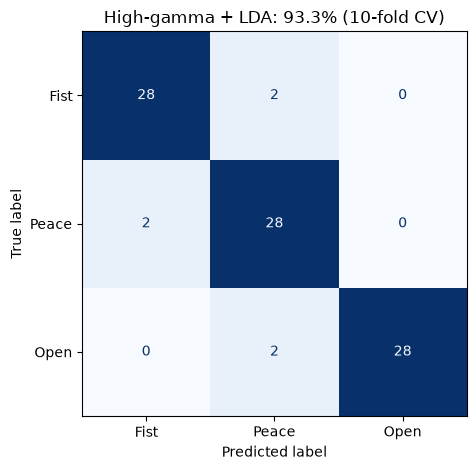

In [4]:
%matplotlib inline
import os
import runpy

previous_directory = Path.cwd()
try:
    os.chdir(source_directory)
    runpy.run_path("classify.py", run_name="__main__")
finally:
    os.chdir(previous_directory)


## 3. 다음 단계: whitening 추가 전후 비교

기존 코드의 결과를 확인한 후 이 단계의 코드를 추가합니다.

- 추가 위치: notch 필터 뒤, 50–300 Hz bandpass 앞
- 방법: 전극별 10차 spectral whitening
- 유지할 조건: 특징 추출, LDA, 평가 방식, CV 분할
- 확인할 결과: 정확도 평균·표준편차, 혼동행렬, 정답을 섞은 대조 실험

한 조건만 바꿔야 결과의 차이를 whitening의 효과로 해석할 수 있습니다.
